In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
dfs = []
for i in range(1, 22):
    id = ('0' + str(i)) if i < 10 else str(i)
    df = pd.read_csv(f"data\data_{id}_socio_economic_102_v20260313.csv", sep=";")
    dfs.append(df)
print(f"Загружено {len(dfs)} таблиц.")

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vorkm\AppData\Local\Temp\ipykernel_19872\3193740685.py:4: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv(f"data\data_{id}_socio_economic_102_v20260313.csv", sep=";")


Загружено 21 таблиц.


In [4]:
for df in dfs:
    print(f"Раздел: {df['section'].unique()}, размер: {df.shape}")

Раздел: ['Население'], размер: (76777, 14)
Раздел: ['Труд'], размер: (44832, 14)
Раздел: ['Уровень жизни населения'], размер: (132336, 14)
Раздел: ['Образование'], размер: (56544, 14)
Раздел: ['Здравоохранение'], размер: (66912, 14)
Раздел: ['Культура, отдых и туризм'], размер: (37728, 14)
Раздел: ['Земельные ресурсы и охрана окружающей природной среды'], размер: (22848, 14)
Раздел: ['Валовой региональный продукт'], размер: (16896, 14)
Раздел: ['Основные фонды'], размер: (8928, 14)
Раздел: ['Инвестиции'], размер: (10080, 14)
Раздел: ['Организации' 'Предприятия и организации'], размер: (65184, 14)
Раздел: ['Промышленное производство'], размер: (22416, 14)
Раздел: ['Сельское, лесное хозяйство, рыболовство и рыбоводство'], размер: (150528, 14)
Раздел: ['Строительство'], размер: (45888, 14)
Раздел: ['Торговля и услуги населению'], размер: (49920, 14)
Раздел: ['Транспорт'], размер: (31872, 14)
Раздел: ['Информационные и коммуникационные технологии'], размер: (32736, 14)
Раздел: ['Наука и ин

In [91]:
grp_2024 = pd.read_csv('D:\EDA HW\IPS\cursach\data\grp_2024.csv')
grp_2024['object_name'] = grp_2024['object_name'].str.strip()
grp_2024_region_mapping = {
    'г.Москва': 'Москва',
    'Архангельская область без авт.округа': 'Архангельская область (без автономного округа)', 
    'в т.ч. Ненецкий автономный округ': 'Ненецкий автономный округ',
    'г.Санкт-Петербург': 'Санкт-Петербург',
    'г.Севастополь': 'Севастополь',
    'Тюменская область (без Ханты-Мансийского авт.округа-Югра и Ямало-Ненецкого авт.округа)': 'Тюменская область (без автономных округов)',
    'в т.ч. Ханты-Мансийский автономный округ': 'Ханты-Мансийский автономный округ — Югра',
    'Карачаево-Черкесская .': 'Карачаево-Черкесская Республика',
    'Кемеровская область-Кузбасс': 'Кемеровская область',
    'Еврейская автономная  область': 'Еврейская автономная область',
    'Кабардино-Балкарская': 'Кабардино-Балкарская Республика',
    'Северная Осетия-Алания': 'Республика Северная Осетия — Алания'
}
grp_2024['object_name'] = grp_2024['object_name'].replace(grp_2024_region_mapping)
grp_2024 = grp_2024.loc[grp_2024['object_name'].isin(df['object_name'].unique())]
grp_2024['year'] = grp_2024['year'].replace({'2,024': 2024})
grp_2024['indicator_value'] = grp_2024['indicator_value'].str.replace(',', '', regex=False).astype(float) / 1000 # приводим к млн. руб из тыс. руб.
grp_2024['indicator_unit'] = 'Миллионов рублей'
grp_2024['indicator_name'] = 'Валовой региональный продукт'
grp_2024.head(10)

<>:1: SyntaxWarning: invalid escape sequence '\E'
<>:1: SyntaxWarning: invalid escape sequence '\E'
C:\Users\vorkm\AppData\Local\Temp\ipykernel_19872\346016060.py:1: SyntaxWarning: invalid escape sequence '\E'
  grp_2024 = pd.read_csv('D:\EDA HW\IPS\cursach\data\grp_2024.csv')
C:\Users\vorkm\AppData\Local\Temp\ipykernel_19872\346016060.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grp_2024['year'] = grp_2024['year'].replace({'2,024': 2024})


,indicator_name,indicator_value,object_name,year,indicator_unit
2,Валовой региональный продукт,1.417239e+06,Белгородская область,2024,Миллионов рублей
3,Валовой региональный продукт,5.246862e+05,Брянская область,2024,Миллионов рублей
4,Валовой региональный продукт,7.331304e+05,Владимирская область,2024,Миллионов рублей
5,Валовой региональный продукт,1.357426e+06,Воронежская область,2024,Миллионов рублей
6,Валовой региональный продукт,3.386484e+05,Ивановская область,2024,Миллионов рублей
7,Валовой региональный продукт,6.898088e+05,Калужская область,2024,Миллионов рублей
8,Валовой региональный продукт,2.860680e+05,Костромская область,2024,Миллионов рублей
9,Валовой региональный продукт,6.825727e+05,Курская область,2024,Миллионов рублей
10,Валовой региональный продукт,9.205940e+05,Липецкая область,2024,Миллионов рублей
11,Валовой региональный продукт,7.601747e+06,Московская область,2024,Миллионов рублей


In [92]:
time_period = list(range(2019, 2025))
regions_to_delete = ['Архангельская область (с автономным округом)', 'Тюменская область (с автономными округами)']

def clean_df(df, indicators):
    df = df.loc[df['indicator_name'].isin(indicators) & (df['object_level'] == 'Регион') & (df['year'].isin(time_period))][['indicator_name', 'indicator_value', 'object_name', 'year', 'indicator_unit']]
    df = df.loc[~df['object_name'].isin(regions_to_delete)]
    df.replace([-99999999.00, -77777777.00], np.nan, inplace=True)
    print(f"NAN values: {df.isna().sum().sum()}")
    df['indicator_value'] = df.groupby(['indicator_name', 'year'])['indicator_value'].transform(lambda x: x.fillna(x.mean()))
    return df

demography_df = dfs[0]
demography_indicators = ['Суммарный коэффициент рождаемости', 'Коэффициенты младенческой смертности']
demography_df = clean_df(demography_df, demography_indicators)

grp_df = dfs[7]
grp_indicators = ['Валовой региональный продукт']
grp_df = clean_df(grp_df, grp_indicators)
grp_df = pd.concat([grp_df, grp_2024])

labor_df = dfs[1]
labor_indicators = ['Уровень безработицы: Уровень безработицы']
labor_df = clean_df(labor_df, labor_indicators)

life_df = dfs[2]
life_indicators = ['Медианный среднедушевой денежный доход населения',]
life_df = clean_df(life_df, life_indicators)

price_df = dfs[-2]
price_indicators = ['Индексы потребительских цен на продовольственные товары', 'Индексы потребительских цен (тарифов) на услуги']
price_df = clean_df(price_df, price_indicators)

science_df = dfs[-4]
science_indicators = ['Внутренние затраты на научные исследования и разработки']
science_df = clean_df(science_df, science_indicators)

health_df = dfs[4]
health_indicators = ['Численность населения на одну больничную койку', 'Численность среднего медицинского персонала: На 10000 человек населения']
health_df = clean_df(health_df, health_indicators)

transport_df = dfs[-6]
transport_indicators = ['Пассажирооборот автобусов общего пользования', 'Число дорожно-транспортных происшествий на 100000 человек населения']
transport_df = clean_df(transport_df, transport_indicators)

trade_df = dfs[-7]
trade_indicators = ['Оборот общественного питания на душу населения']
trade_df = clean_df(trade_df, trade_indicators)

building_df = dfs[-8]
building_indicators = ['Ввод в действие жилых домов: На 1000 человек населения']
building_df = clean_df(building_df, building_indicators)

industry_df = dfs[-10]
industry_indicators = ['Индексы промышленного производства: В соответствии с ОКВЭД2']
industry_df = clean_df(industry_df, industry_indicators)

agriculture_df = dfs[-9]
agriculture_indicators = ['Индексы производства продукции сельского хозяйства: Всего']
agriculture_df = clean_df(agriculture_df, agriculture_indicators)

df = pd.concat([grp_df, demography_df, life_df, labor_df, price_df, science_df, health_df, transport_df, trade_df, building_df, industry_df, agriculture_df], axis=0)
print(f"Итоговый размер: {df.shape}")

indicator_counts = df['indicator_value'].value_counts().sort_index()
print(indicator_counts)
print(df.isna().sum())

NAN values: 0
NAN values: 0
NAN values: 0
NAN values: 0
NAN values: 0
NAN values: 10
NAN values: 0
NAN values: 2
NAN values: 0
NAN values: 0
NAN values: 0
NAN values: 6
Итоговый размер: (8160, 5)
indicator_value
8.710000e-01    1
8.800000e-01    1
8.880000e-01    1
9.330000e-01    1
9.590000e-01    1
               ..
2.026072e+07    1
2.426576e+07    1
2.772639e+07    1
3.184805e+07    1
3.233900e+07    1
Name: count, Length: 4335, dtype: int64
indicator_name     0
indicator_value    0
object_name        0
year               0
indicator_unit     0
dtype: int64


In [93]:
mapping = {
    'Ввод в действие жилых домов: На 1000 человек населения': 'Ввод жилья',
    'Внутренние затраты на научные исследования и разработки': 'Затраты на науку',
    'Индексы потребительских цен (тарифов) на услуги': 'ИПЦ на услуги',
    'Индексы потребительских цен на продовольственные товары': 'ИПЦ на продовольствие',
    'Медианный среднедушевой денежный доход населения': 'Медианный доход',
    'Оборот общественного питания на душу населения': 'Оборот общепита',
    'Объем транспортных услуг: На душу населения': 'Транспортные услуги',
    'Пассажирооборот автобусов общего пользования': 'Пассажирооборот автобусов',
    'Темпы прироста численности населения': 'Прирост населения',
    'Удельный вес городского населения в общей численности населения': 'Доля городского населения',
    'Уровень безработицы: Уровень безработицы': 'Уровень безработицы',
    'Численность населения на одну больничную койку': 'Население на койку',
    'Численность среднего медицинского персонала: На 10000 человек населения': 'Средний медперсонал',
    'Число дорожно-транспортных происшествий на 100000 человек населения': 'ДТП на 100 тыс. чел.',
    'Индексы промышленного производства: В соответствии с ОКВЭД2': 'Индекс промышленности',
    'Индексы производства продукции сельского хозяйства: Всего': 'Индекс c/х',
    'Валовой региональный продукт': 'ВРП',
    'Валовой региональный продукт на душу населения': 'ВРП на душу',
    'Коэффициенты младенческой смертности': 'Коэф. млад. смертности',
    'Суммарный коэффициент рождаемости': 'Коэф. рождаемости'
}
df['indicator_name'] = df['indicator_name'].replace(mapping)
pd.set_option('display.max_colwidth', None)
display(df[['indicator_name', 'indicator_unit']].drop_duplicates())

,indicator_name,indicator_unit
1458,ВРП,Миллионов рублей
17682,Коэф. млад. смертности,"Число детей, умерших в возрасте до 1 года, на 1000 родившихся живыми"
58747,Коэф. рождаемости,Число детей на 1 женщину
11910,Медианный доход,"В месяц, рублей"
9234,Уровень безработицы,"По данным выборочных обследований рабочей силы, в процентах"
2322,ИПЦ на услуги,"Декабрь к декабрю предыдущего года, в процентах"
6930,ИПЦ на продовольствие,"Декабрь к декабрю предыдущего года, в процентах"
18,Затраты на науку,Миллионов рублей
55410,Население на койку,"На конец года, человек"
60018,Средний медперсонал,"На конец года, человек"


In [112]:
# Статистика по показателям (агрегация по всем регионам и годам)
summary = df.groupby('indicator_name')['indicator_value'].agg([
    'count', 'mean', 'min', 'median', 'max', 
    lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)
]).round(2)
summary.columns = ['Число наблюдений', 'Среднее', 'Минимум', 'Медиана', 'Максимум', 'Q25', 'Q75']

summary = summary.rename_axis(None, axis='index')
display(summary)

,Число наблюдений,Среднее,Минимум,Медиана,Максимум,Q25,Q75
ВРП,510,1467544.94,56847.60,688060.35,32339001.60,348141.05,1379492.08
Ввод жилья,510,589.26,26.00,547.50,2063.00,419.25,689.50
ДТП на 100 тыс. чел.,510,103.64,10.40,103.89,223.80,83.81,125.10
Затраты на науку,510,17140.78,31.47,2296.64,670681.71,889.78,9305.34
ИПЦ на продовольствие,510,108.35,100.00,108.80,120.20,106.60,110.80
ИПЦ на услуги,510,107.13,100.00,106.20,119.30,103.60,110.68
Индекс c/х,510,101.62,54.60,101.20,149.00,96.43,106.30
Индекс промышленности,510,104.83,63.30,104.10,191.10,100.10,108.90
Коэф. млад. смертности,510,4.71,1.40,4.40,25.70,3.80,5.30
Коэф. рождаемости,510,1.48,0.87,1.44,2.78,1.30,1.60


In [113]:
print(summary.to_latex(index=True,
                  formatters={"name": str.upper},
                  float_format="{:.1f}".format,
                  ))


\begin{tabular}{lrrrrrrr}
\toprule
 & Число наблюдений & Среднее & Минимум & Медиана & Максимум & Q25 & Q75 \\
\midrule
ВРП & 510 & 1467544.9 & 56847.6 & 688060.3 & 32339001.6 & 348141.0 & 1379492.1 \\
Ввод жилья & 510 & 589.3 & 26.0 & 547.5 & 2063.0 & 419.2 & 689.5 \\
ДТП на 100 тыс. чел. & 510 & 103.6 & 10.4 & 103.9 & 223.8 & 83.8 & 125.1 \\
Затраты на науку & 510 & 17140.8 & 31.5 & 2296.6 & 670681.7 & 889.8 & 9305.3 \\
ИПЦ на продовольствие & 510 & 108.3 & 100.0 & 108.8 & 120.2 & 106.6 & 110.8 \\
ИПЦ на услуги & 510 & 107.1 & 100.0 & 106.2 & 119.3 & 103.6 & 110.7 \\
Индекс c/х & 510 & 101.6 & 54.6 & 101.2 & 149.0 & 96.4 & 106.3 \\
Индекс промышленности & 510 & 104.8 & 63.3 & 104.1 & 191.1 & 100.1 & 108.9 \\
Коэф. млад. смертности & 510 & 4.7 & 1.4 & 4.4 & 25.7 & 3.8 & 5.3 \\
Коэф. рождаемости & 510 & 1.5 & 0.9 & 1.4 & 2.8 & 1.3 & 1.6 \\
Медианный доход & 510 & 32660.3 & 13655.0 & 28356.2 & 131225.3 & 23029.0 & 37098.9 \\
Население на койку & 510 & 123.4 & 73.6 & 122.3 & 229.8 & 108.

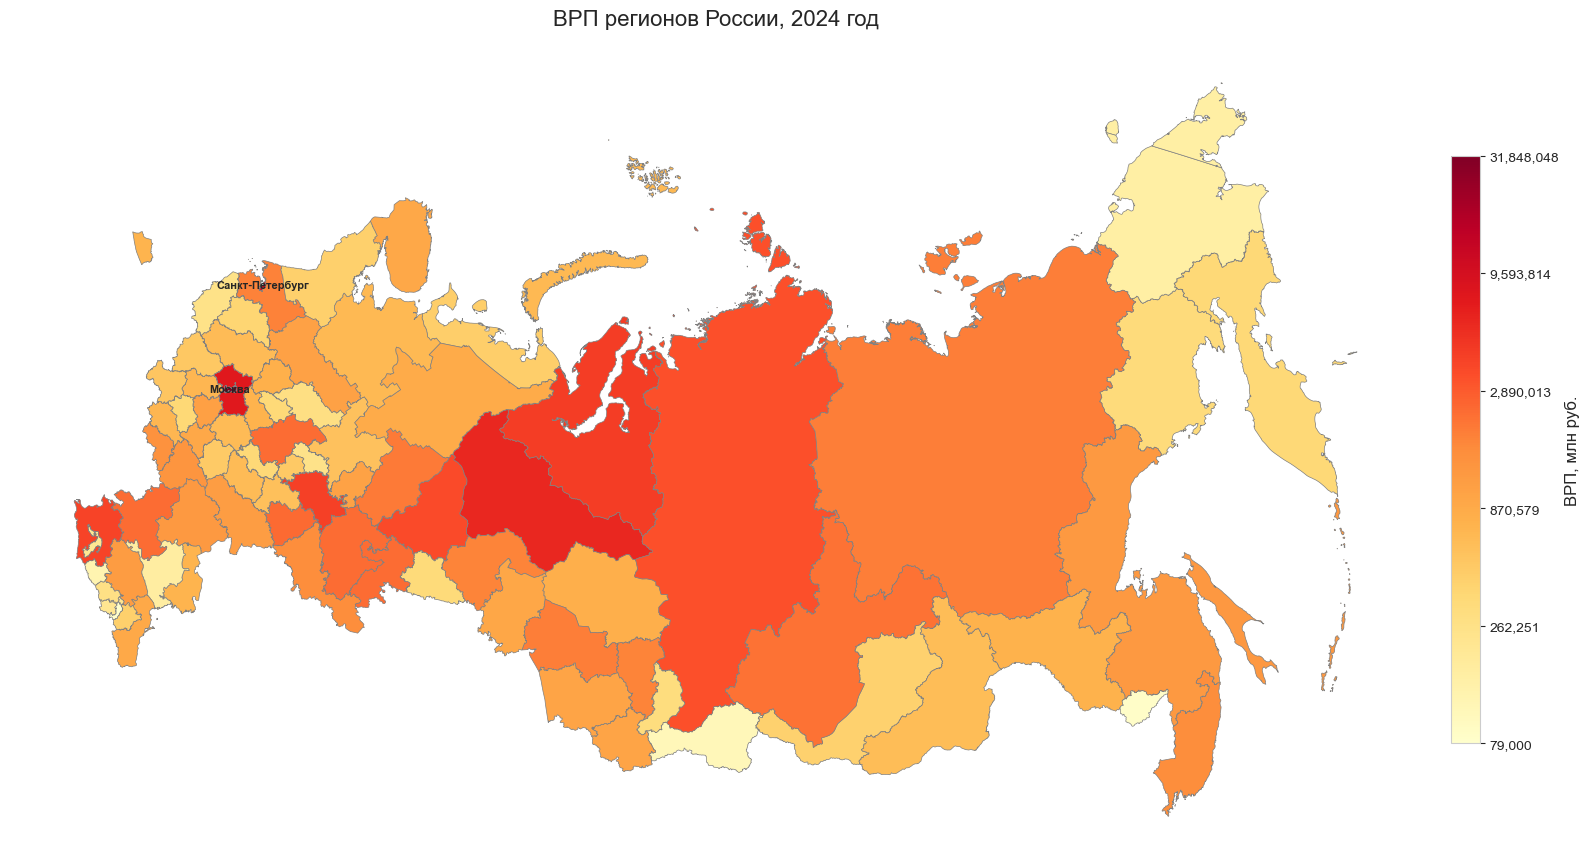

✅ Карта сохранена: russia_gdp_2024_map.png


In [157]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from thefuzz import process

GEOJSON_URL = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/russia.geojson"
gdf = gpd.read_file(GEOJSON_URL)
region_col = "name"

NAME_FIXES = {
    "Адыгея": "Республика Адыгея",
    "Алтай": "Республика Алтай",
    "Башкортостан": "Республика Башкортостан",
    "Бурятия": "Республика Бурятия",
    "Дагестан": "Республика Дагестан",
    "Ингушетия": "Республика Ингушетия",
    "Марий Эл": "Республика Марий Эл",
    "Мордовия": "Республика Мордовия",
    "Татарстан": "Республика Татарстан",
    "Тыва": "Республика Тыва",
    "Хакасия": "Республика Хакасия",
    "Чувашия": "Чувашская Республика",
    "Карачаево-Черкесская республика": "Карачаево-Черкесская Республика",
    "Чеченская республика": "Чеченская Республика",
    "Кабардино-Балкарская республика": "Кабардино-Балкарская Республика",
    "Удмуртская республика": "Удмуртская Республика",
    "Ханты-Мансийский автономный округ - Югра": "Ханты-Мансийский автономный округ — Югра",
    "Северная Осетия - Алания": "Республика Северная Осетия — Алания",
    "Тюменская область": "Тюменская область (без автономных округов)",
    "Архангельская область": "Архангельская область (без автономного округа)",
}

gdf["object_name"] = gdf[region_col].replace(NAME_FIXES)
gdf.loc[gdf[region_col] == "Чувашия", region_col] = "Чувашская Республика"

# Fuzzy matching
rosstat_names = df[df['indicator_name'] == 'ВРП']['object_name'].unique().tolist()
gis_names = gdf[region_col].tolist()

mapping = {}
for gis_name in gis_names:
    best_match, score = process.extractOne(gis_name, rosstat_names)
    if score > 85:
        mapping[gis_name] = best_match

gdf["object_name"] = gdf[region_col].map(mapping).fillna(gdf[region_col])

# ВРП за 2024 год
gdp_2024 = (
    df[(df['indicator_name'] == 'ВРП') & (df['year'] == 2024)]
    [['object_name', 'indicator_value']]
    .rename(columns={'indicator_value': 'gdp'})
)

gdf = gdf.merge(gdp_2024, on="object_name", how="left")

missing = gdf[gdf["gdp"].isna()][region_col].tolist()
if missing:
    print(f"⚠️ Не удалось сопоставить {len(missing)} регионов:")
    for m in missing[:10]:
        print(f"  • {m}")

# Репроекция
gdf = gdf.to_crs(epsg=4326)
gdf = gdf.to_crs(
    "+proj=aeqd +lat_0=60 +lon_0=100 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
)

# Логарифмическая шкала — ВРП очень неравномерен
gdf["gdp_log"] = np.log10(gdf["gdp"].clip(lower=1))

fig, ax = plt.subplots(1, 1, figsize=(16, 10))

gdf.plot(
    column="gdp_log",
    cmap="YlOrRd",
    ax=ax,
    linewidth=0.5,
    edgecolor="gray",
    legend=False,
    missing_kwds={"color": "lightgrey", "label": "Нет данных"},
)

# Colorbar с оригинальными значениями (не логарифмом)
gdp_min = gdf["gdp"].min()
gdp_max = gdf["gdp"].max()
log_min = np.log10(max(gdp_min, 1))
log_max = np.log10(gdp_max)

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=mcolors.Normalize(vmin=log_min, vmax=log_max)
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("ВРП, млн руб.", fontsize=12)

# Тики colorbar в читаемых значениях
tick_values = np.logspace(log_min, log_max, num=6)
cbar.set_ticks(np.log10(tick_values))
cbar.set_ticklabels([f"{v:,.0f}" for v in tick_values])

ax.set_title("ВРП регионов России, 2024 год", fontsize=16, pad=15)
ax.axis("off")

# Подписи для Москвы и СПб
for _, row in gdf.iterrows():
    if pd.notna(row["gdp"]) and row[region_col] in ["Москва", "Санкт-Петербург"]:
        ax.text(
            row["geometry"].centroid.x,
            row["geometry"].centroid.y,
            row[region_col],
            ha="center", va="center",
            fontsize=8, fontweight="bold",
        )

plt.tight_layout()
plt.savefig("russia_gdp_2024_map.png", dpi=300, bbox_inches="tight")
plt.show()
print("✅ Карта сохранена: russia_gdp_2024_map.png")

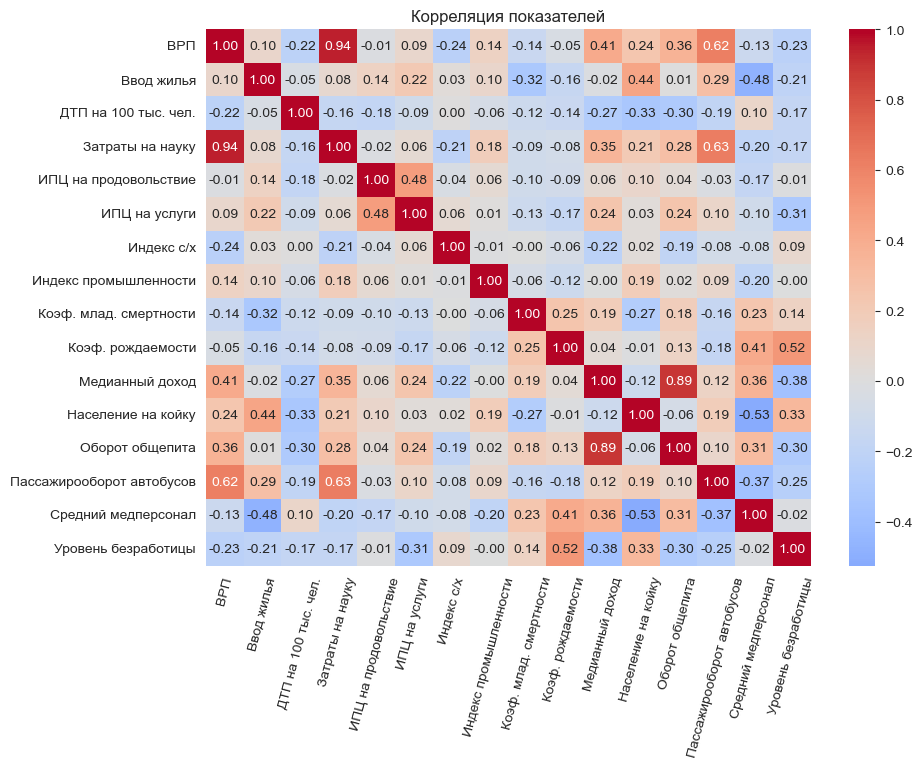

In [162]:
wide = df.pivot_table(
    index=['object_name', 'year'], 
    columns='indicator_name', 
    values='indicator_value'
)

corr = wide.corr()
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция показателей")
plt.tight_layout()
plt.ylabel(None)
plt.xticks(rotation=75)
plt.xlabel(None)
plt.show()


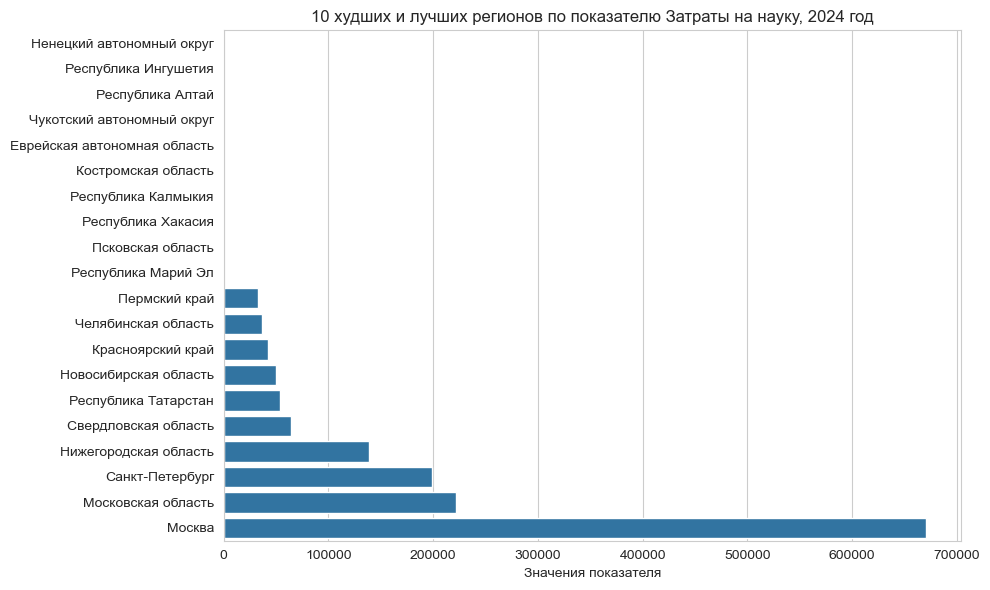

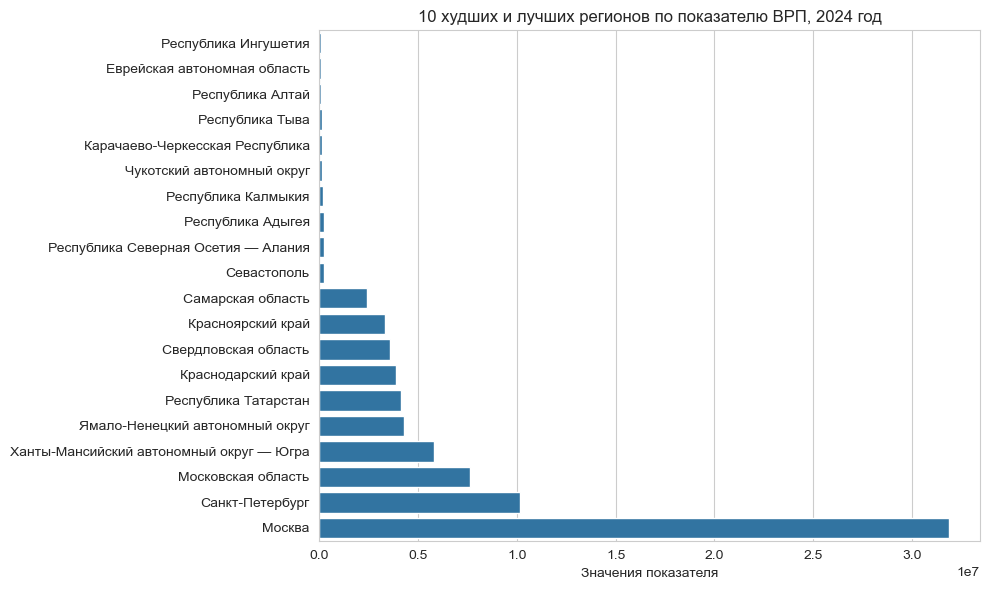

In [161]:
def plot_top_bottom_regions(df, indicator, year, n=10):
    subset = df[(df['indicator_name'] == indicator) & (df['year'] == year)]
    
    top = subset.nlargest(n, 'indicator_value')[['object_name', 'indicator_value']]
    bottom = subset.nsmallest(n, 'indicator_value')[['object_name', 'indicator_value']]

    plot_df = pd.concat([top, bottom], ignore_index=True).sort_values(by='indicator_value')
    
    sns.barplot(data=plot_df, x='indicator_value', y='object_name', legend=False)
    plt.title(f"{n} худших и лучших регионов по показателю {indicator}, {year} год")
    plt.xlabel("Значения показателя")
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

plot_top_bottom_regions(df, indicator="Затраты на науку", year=2024)
plot_top_bottom_regions(df, indicator="ВРП", year=2024)

In [172]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled['indicator_value'] = (
    df_scaled
    .groupby(['year', 'indicator_name'])['indicator_value']
    .transform(lambda x: scaler.fit_transform(x.values.reshape(-1, 1)).ravel())
)

def plot_top_bottom_regions(df, indicator, year, n=10):
    subset = df[(df['indicator_name'] == indicator) & (df['year'] == year)]
    
    top = subset.nlargest(n, 'indicator_value')[['object_name', 'indicator_value']]
    bottom = subset.nsmallest(n, 'indicator_value')[['object_name', 'indicator_value']]

    plot_df = pd.concat([top, bottom], ignore_index=True).sort_values(by='indicator_value')
    
    sns.barplot(data=plot_df, x='indicator_value', y='object_name', legend=False)
    plt.title(f"{n} худших и лучших регионов по показателю {indicator}, {year} год")
    plt.xlabel("Значения показателя")
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

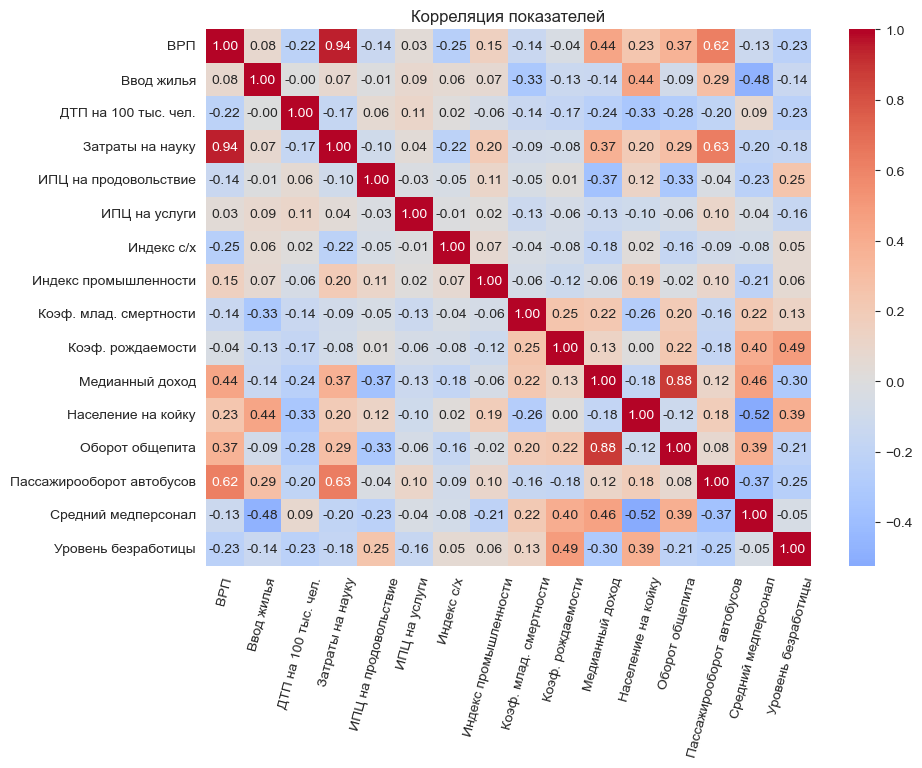

In [173]:
wide = df_scaled.pivot_table(
    index=['object_name', 'year'], 
    columns='indicator_name', 
    values='indicator_value'
)

corr = wide.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция показателей")
plt.tight_layout()
plt.ylabel(None)
plt.xticks(rotation=75)
plt.xlabel(None)
plt.show()


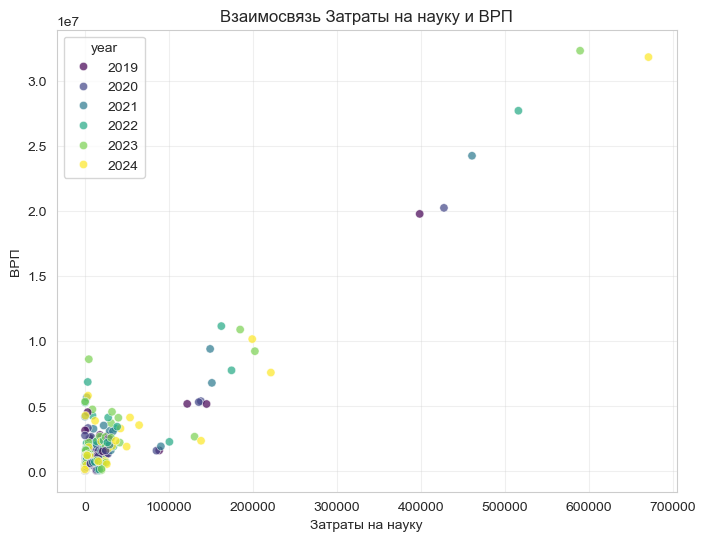

In [144]:
indicators = ["Затраты на науку", "ВРП"] 

scatter_df = df[df['indicator_name'].isin(indicators)].pivot_table(
    index=['object_name', 'year'], 
    columns='indicator_name', 
    values='indicator_value'
).reset_index()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=scatter_df, x=indicators[0], y=indicators[1], 
                hue='year', palette='viridis', alpha=0.7)
plt.title(f"Взаимосвязь {indicators[0]} и {indicators[1]}")
plt.grid(True, alpha=0.3)
plt.show()

In [174]:
import tensorly as tl
import numpy as np

tl.set_backend('numpy')

tensor_df = (
    df
    .set_index(['object_name', 'indicator_name', 'year'])['indicator_value']
    .to_xarray()
)

map_object    = dict(enumerate(tensor_df.coords['object_name'].values))
map_indicator = dict(enumerate(tensor_df.coords['indicator_name'].values))
map_year      = dict(enumerate(tensor_df.coords['year'].values))

tensor_df = tensor_df.fillna(0)
tl_tensor = tensor_df.values
print(tensor_df.shape)
scaler = sklearn.preprocessing.StandardScaler()
for t in range(tl_tensor.shape[2]):
    tl_tensor[..., t] = scaler.fit_transform(tl_tensor[..., t])
tensor_df.values = tl_tensor
tensor_df.to_netcdf("tensor_df_6.nc", mode='w')

(85, 16, 6)
